# A/B-тест Cookie Cats — план работы

**Датасет:** Mobile Games A/B Testing (Cookie Cats, Kaggle)
**Стек:** Jupyter + pandas, scipy/statsmodels
**Суть теста:** gate (ворота-блокировка) переносят с 30 уровня (`gate_30`, контроль) на 40 (`gate_40`, тест).
**Бизнес-вопрос:** где ставить gate, чтобы не терять retention.

**Поля датасета:**
- `userid` — id игрока
- `version` — группа: `gate_30` / `gate_40`
- `sum_gamerounds` — число сыгранных раундов в первые 14 дней
- `retention_1` — вернулся ли на 1-й день (bool)
- `retention_7` — вернулся ли на 7-й день (bool)

---

## Этап 0. Контекст и гипотеза (до кода)

---

### Статистические гипотезы

- **H0:** retention_7(gate_30) = retention_7(gate_40) — разницы нет.
- **H1:** retention_7(gate_30) ≠ retention_7(gate_40) — разница есть *(двусторонний тест)*.

### Продуктовые гипотезы о механизме
*(что может стоять за разницей, если она найдётся)*

- **A)** Отодвинутый gate → больше свободной игры → сильнее вовлечение → **выше** возврат.
- **B)** Отодвинутый gate → выгорание за длинные сессии → **ниже** возврат.

Тест покажет, какой механизм перевесил.

### Параметры решения

| Параметр | Значение |
|---|---|
| Уровень значимости α | 0.05 |
| Направление теста | двусторонний |
| MDE | 1 п.п. по retention_7 |

## Этап 1. Загрузка и первичный осмотр

---

**📋 План этапа:**
- [X] Загрузить `cookie_cats.csv` через `pd.read_csv()`
- [X] Осмотреть данные: `.head()`, `.info()`, `.describe()` — типы, размер, диапазоны
- [X] Проверить пропуски: `.isna().sum()`
- [X] Проверить дубликаты по игроку: `df['userid'].duplicated().sum()`
- [X] Проверить, что групп ровно две: `df['version'].value_counts()`

**Загрузка данных**

In [23]:
# Импортируем библиотеку
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy.stats import chisquare
from scipy.stats import norm

df = pd.read_csv('data/cookie_cats.csv')

**Осмотр: типы, размер, диапазоны**

In [24]:
# Типы
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [25]:
# размер
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [26]:
# диапазон
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


> **Чтение `describe()`:**
> - Среднее (52) > медианы (16) → распределение скошено вправо.
> - Небольшая группа игроков тянет значения вверх, основная масса играет мало.
> - `max = 49854` — явный выброс.
> - `min = 0` — интересное наблюдение для оценки качества трафика (поставили и не сыграли).

**Пропуски**

In [27]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

**Дубликаты по игроку** (ожидаем 0)

In [28]:
df['userid'].duplicated().sum()

np.int64(0)

**Группы `version`** (ожидаем ровно две)

In [29]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

> **✅ Вывод этапа 1 — здоровье данных**
>
> | Проверка | Результат |
> |---|---|
> | Размер выборки | 90 189 игроков — достаточно с запасом |
> | Пропуски (NaN) | нет |
> | Дубли `userid` | нет, все ID уникальны |
> | Группы `version` | ровно две: `gate_30` (44 700) и `gate_40` (45 489) |
> | Типы данных | корректны; `retention_1` и `retention_7` — булевы (удобно для долей) |
> | Распределение `sum_gamerounds` | сильный правый скос: медиана 16 при среднем 52, std 195, max 49 854 |
>
> **Флаги на этап 2:** выброс `sum_gamerounds = 49 854` (кандидат на исключение) и скошенность распределения — повлияют на выбор стат-теста.
>
> **Итог:** данные структурно чистые, группы сбалансированы (≈49.6 / 50.4%), готовы к проверке валидности эксперимента.

## Этап 2. Валидность эксперимента (самый пропускаемый этап)

---

> ⚠️ Если эксперимент сломан — дальше считать бессмысленно. Проверяй здесь, а не после выводов.

**📋 План этапа:**
- [X] **Sample Ratio Mismatch (SRM):** размеры групп ожидаем ~50/50. Проверить перекос хи-квадратом (`scipy.stats.chisquare`). Порог тревоги — p < 0.001.
- [X] **Выбросы по `sum_gamerounds`:** найти максимум, решить (убрать/обрезать) и обосновать.
- [X] Сравнить распределение `sum_gamerounds` между группами — нет ли перекоса до всякого эффекта.

**Проверка SRM: перекос групп против ожидаемого 50/50**

In [30]:
# фактические размеры групп
observed = df['version'].value_counts().values

n = len(df)
expected = [n/2, n/2]
chi2, p = chisquare(f_obs=observed, f_exp=expected)

print(f'chi2 = {chi2:.4f}, p-value = {p:.4f}')


chi2 = 6.9024, p-value = 0.0086


> **✅ Вывод по SRM:** хи-квадрат дал p = 0.0086 — формально значимо при α = 0.05, но фактический перекос составляет лишь 49.56% против ожидаемых 50%.
>
> На выборке в 90k наблюдений хи-квадрат избыточно чувствителен к ничтожным отклонениям. По порогу SRM-проверки (p < 0.001) расхождение не дотягивает до тревожного.
>
> Практический размер расхождения — 0.44%, это шум, а не поломка.
>
> **Итог:** рандомизация здорова, SRM не обнаружен, эксперимент валиден.

**Поиск выбросов по `sum_gamerounds`** (топ-10 по убыванию)

In [31]:
df.sort_values('sum_gamerounds', ascending=False).head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


In [32]:
df_clean = df[df['sum_gamerounds'] < 49854]

> **✅ Решение по выбросу:** `userid=6390605` (49 854 раунда) — подтверждённый бот/сбой (≈3500 раундов/день нереально для человека).
>
> Создан `df_clean` без этой точки — для анализа и визуализации `sum_gamerounds`.
>
> Retention считаем на полном `df`: там выброс не искажает доли, а валидные `retention_*` этого игрока сохраняются.

**Сравнение распределения `sum_gamerounds` между группами**

In [33]:
df_clean.groupby('version')['sum_gamerounds'].describe()

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44699.0,51.342111,102.057598,0.0,5.0,17.0,50.0,2961.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


> **✅ Вывод этапа 2 — валидность**
>
> | Проверка | Результат |
> |---|---|
> | Размер групп (SRM) | gate_30: 44 700, gate_40: 45 489. Перекос 49.56% vs 50% |
> | Хи-квадрат SRM | p = 0.0086 — выше порога 0.001; на выборке 90k шум сверхчувствительности, не поломка |
> | Выброс | `userid=6390605` (49 854 раунда) — бот/сбой, вынесен в `df_clean` для анализа `sum_gamerounds` |
> | Баланс групп по `sum_gamerounds` | mean 51.34 vs 51.30, медиана 17 vs 16 — группы неотличимы |
>
> **Итог:** эксперимент валиден. Группы сбалансированы по размеру и стартовому поведению. Разницу в ретеншене (если найдётся) можно приписывать переносу gate, а не дисбалансу.

## Этап 3. Разведочный анализ (EDA)

---

**📋 План этапа:**
- [X] Гистограмма `sum_gamerounds` — линейная + лог-шкала (распределение сильно скошено вправо).
- [X] Доля игроков с `sum_gamerounds == 0` (поставили и не открыли).
- [X] Базовые доли `retention_1` и `retention_7` по группам — просто `.mean()`, без тестов.

**Гистограмма `sum_gamerounds`** (линейная + лог-шкала)

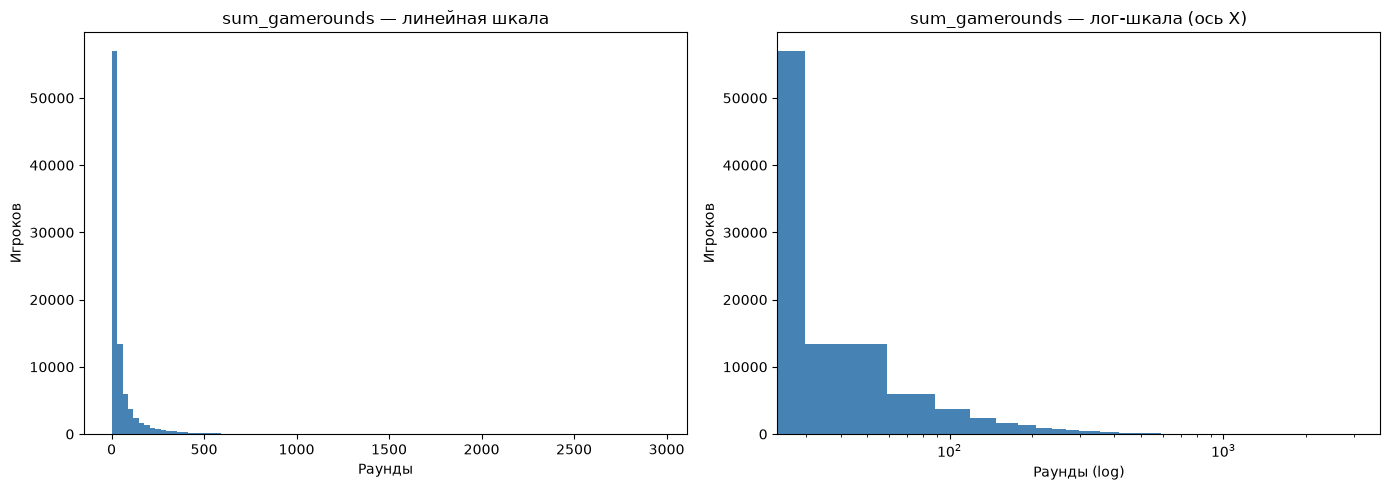

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Линейная шкала — видно, как всё прижато влево
axes[0].hist(df_clean['sum_gamerounds'], bins=100, color='steelblue')
axes[0].set_title('sum_gamerounds — линейная шкала')
axes[0].set_xlabel('Раунды')
axes[0].set_ylabel('Игроков')

# Лог-шкала по X — раскрывает структуру распределения
axes[1].hist(df_clean['sum_gamerounds'], bins=100, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_title('sum_gamerounds — лог-шкала (ось X)')
axes[1].set_xlabel('Раунды (log)')
axes[1].set_ylabel('Игроков')

plt.tight_layout()
plt.show()

**Доля игроков с 0 раундов**

In [35]:
zero_players = (df['sum_gamerounds'] == 0).sum()
zero_share = (df['sum_gamerounds'] == 0).mean()
print(f'Игроков с 0 раундов: {zero_players} ({zero_share:.1%})')

Игроков с 0 раундов: 3994 (4.4%)


> **Наблюдение:** 3994 игрока (4.4%) установили игру и не сыграли ни одного раунда.
>
> Показатель умеренный — большинство хотя бы пробует играть. Проблема не в нулях, а в быстром отвале на ранних раундах (медиана всего 16).

**Базовые доли retention по группам** (без тестов)

In [36]:
df.groupby('version')[['retention_1', 'retention_7']].mean()

,retention_1,retention_7
version,,
gate_30,0.448188,0.190201
gate_40,0.442283,0.182000


> **✅ Вывод этапа 3 — EDA**
>
> **Распределение `sum_gamerounds`:** сильный правый скос (типичная F2P-структура). Медиана 16 при среднем 52 — среднее завышено хвостом вовлечённых. Для стат-анализа этой метрики → непараметрические методы.
>
> **Доля нулевых игроков:** 3994 (4.4%) — установили и не сыграли ни разу. Показатель умеренный; основная зона потерь — ранний отвал (половина игроков ≤16 раундов).
>
> **Базовые доли retention по группам:**
>
> | Метрика | gate_30 | gate_40 | Разница |
> |---|---|---|---|
> | retention_1 | 44.82% | 44.23% | −0.59 п.п. |
> | retention_7 | 19.02% | 18.20% | −0.82 п.п. |
>
> **Наблюдение:** в обеих метриках gate_40 ниже — перенос gate дальше скорее ухудшает удержание (в пользу теории «выгорания», а не «вовлечения»). Разница мала (<MDE 1 п.п.). Статзначимость — на этапе 5; без теста выводы о реальности эффекта не делаем.

## Этап 4. Описательная статистика по группам

---

**📋 План этапа:**
- [X] Сводная таблица через `groupby('version')`: по каждой группе — `n`, доли `retention_1` / `retention_7`, mean и median `sum_gamerounds`, строка `delta`.

**Сводная таблица по группам**

In [37]:
# retention_1 и retention_7 берём с полного df (доли), sum_gamerounds — с df_clean (без выброса)
t1 = df.groupby('version').agg({
    'retention_1': ['mean', 'sum'],
    'retention_7': ['mean', 'sum'],
    'userid': 'size',
})

t2 = df_clean.groupby('version').agg({
    'sum_gamerounds': ['mean', 'median'],
})

t1.columns = ['mean_retention_1', 'sum_retention_1', 'mean_retention_7', 'sum_retention_7', 'n']
t2.columns = ['mean_rounds', 'median_rounds']

# Собираем сводную таблицу и добавляем строку с разницей групп (gate_40 - gate_30)
result_summary_table = t1.join(t2)
result_summary_table.loc['delta'] = result_summary_table.loc['gate_40'] - result_summary_table.loc['gate_30']
result_summary_table

,mean_retention_1,sum_retention_1,mean_retention_7,sum_retention_7,n,mean_rounds,median_rounds
version,,,,,,,
gate_30,0.448188,20034.0,0.190201,8502.0,44700.0,51.342111,17.0
gate_40,0.442283,20119.0,0.182000,8279.0,45489.0,51.298776,16.0
delta,-0.005905,85.0,-0.008201,-223.0,789.0,-0.043335,-1.0


> **✅ Вывод этапа 4:** в сырых данных gate_40 показывает retention ниже на обоих горизонтах (−0.82 п.п. по retention_7), при этом объём игры между группами не различается. Эффект согласован по метрикам, но наблюдаемая разница меньше заложенного MDE — значимость и практическую важность проверяю на этапе 5.

## Этап 5. Статистическая проверка

---

Ключевой этап. **Под каждую метрику — свой тест.** Неправильно подобранный тест — частая ошибка на собесе.

### 5.1. retention_1 и retention_7 (доли, бинарные данные)

**📋 План:**
- [X] **z-тест для двух пропорций** (реализован своей функцией).
- [X] Альтернатива/проверка: **хи-квадрат** на таблице сопряжённости → `scipy.stats.chi2_contingency`.
- [X] ❌ **t-тест здесь некорректен** — данные не непрерывные, это доли (проговорено в выводе).

In [38]:
def z_test_proportions(s1, s2, n1, n2):
    """z-статистика для разницы двух долей (pooled-версия).
    s — число успехов, n — размер группы."""
    p1 = s1 / n1
    p2 = s2 / n2
    p = (s1 + s2) / (n1 + n2)   # общая (pooled) доля — используется в оценке дисперсии
    z = (p1 - p2) / np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    return z

z_test_retention_7 = z_test_proportions(
    result_summary_table.loc['gate_30', 'sum_retention_7'],
    result_summary_table.loc['gate_40', 'sum_retention_7'],
    result_summary_table.loc['gate_30', 'n'],
    result_summary_table.loc['gate_40', 'n'],
)

print(f'z-тест для retention_7 = {z_test_retention_7:.4f}')

z-тест для retention_7 = 3.1644


In [39]:
# Переводим z в p-value. norm.sf(x) — это площадь правого хвоста, P(Z > x).
# Умножаем на 2, потому что тест двусторонний: разница важна в любую сторону.
p_value_retention_7 = 2 * norm.sf(abs(z_test_retention_7))

print(f'z = {z_test_retention_7:.4f}')
print(f'p-value = {p_value_retention_7:.4f}')
print(f'Значимо при alpha=0.05: {p_value_retention_7 < 0.05}')

z = 3.1644
p-value = 0.0016
Значимо при alpha=0.05: True


> **✅ Вывод по retention_7:** z = 3.16, p-value = 0.0016.
>
> p = 0.0016 < 0.05 → **отвергаем H0**. Разница в удержании на 7-й день между группами статистически значима — на случайность её списать нельзя.
>
> z положительный, потому что в функции считаем `gate_30 − gate_40`, а gate_30 выше. Значит **gate на 30 уровне удерживает лучше**, перенос на 40 удержание ухудшил — это в пользу гипотезы «выгорания» (B).
>
> **Почему z-тест, а не t-тест:** retention_7 — это доля (вернулся / не вернулся), а не непрерывное число. Для сравнения долей берут z-тест; t-тест тут не подходит.
>
> **Важно:** p-value говорит только «разница есть», но НЕ говорит, насколько она большая. Сам эффект здесь всего −0.82 п.п. — маленький. Оценка размера эффекта и доверительный интервал — на этапе 6.

In [40]:
# retention_1 — та же функция, подставляем колонки sum_retention_1
z_test_retention_1 = z_test_proportions(
    result_summary_table.loc['gate_30', 'sum_retention_1'],
    result_summary_table.loc['gate_40', 'sum_retention_1'],
    result_summary_table.loc['gate_30', 'n'],
    result_summary_table.loc['gate_40', 'n'],
)

p_value_retention_1 = 2 * norm.sf(abs(z_test_retention_1))

print(f'z = {z_test_retention_1:.4f}')
print(f'p-value = {p_value_retention_1:.4f}')
print(f'Значимо при alpha=0.05: {p_value_retention_1 < 0.05}')

z = 1.7841
p-value = 0.0744
Значимо при alpha=0.05: False


> **✅ Вывод по retention_1:** z = 1.78, p-value = 0.0744.
>
> p = 0.0744 > 0.05 → **H0 НЕ отвергаем**. Разница в удержании на 1-й день (44.82% против 44.23%) статистически незначима — её нельзя отличить от случайного шума.
>
> **Сравни с retention_7:** там p = 0.0016 (значимо), здесь p = 0.0744 (нет). Направление одинаковое — gate_30 везде чуть выше, — но на 1-й день разрыв слишком мал, чтобы быть надёжным, а к 7-му дню он накапливается и становится значимым.
>
> **Итог по обеим метрикам:** эффект от переноса gate проявляется не сразу, а со временем — и бьёт именно по долгому удержанию (retention_7), которое и есть наша первичная метрика.

In [41]:
from scipy.stats import chi2_contingency

# таблица сопряжённости: строки — группы, столбцы — вернулся/не вернулся
contingency = pd.crosstab(df['version'], df['retention_7'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f'chi2 = {chi2:.4f}, p-value = {p:.4f}')


chi2 = 9.9591, p-value = 0.0016


> **✅ Проверка хи-квадратом:** chi2 = 9.96, p = 0.0016 — совпадает с z-тестом (p = 0.0016), т.к. для таблицы 2×2 выполняется χ² = z². Результат по retention_7 подтверждён двумя независимыми методами.

### 5.2. sum_gamerounds (числовая, распределение скошено)

**📋 План:**
- [ ] t-тест на средних **рискован** из-за сильной скошенности и выброса.
- [ ] Надёжнее: **Манн-Уитни** (`scipy.stats.mannwhitneyu`) — сравнивает распределения, не требует нормальности.
- [ ] Ещё надёжнее и нагляднее: **bootstrap** разницы средних (см. этап 6).

### 5.3. Интерпретация p-value

**📋 План:**
- [X] Записать своими словами, что p-value значит и **чего НЕ значит** (это не вероятность того, что H₀ верна, и не размер эффекта) — сделано в выводе по retention_7.

> **✅ Итог этапа 5:** для каждой метрики выбран и обоснован тест, посчитаны p-value, есть корректная интерпретация. retention_7 — значимо (p = 0.0016), retention_1 — незначимо (p = 0.0744). Осталось: тест по `sum_gamerounds` (Манн-Уитни).

## Этап 6. Размер эффекта и доверительные интервалы

---

p-value без размера эффекта — половина ответа. «Значимо» ≠ «важно для бизнеса».

**📋 План этапа:**
- [ ] **Абсолютная разница** retention_7: `p_тест − p_контроль` (в процентных пунктах).
- [ ] **Относительная разница:** на сколько % изменился retention.
- [ ] **Доверительный интервал** для разницы пропорций → `statsmodels.stats.proportion.confint_proportions_2indep`.
- [ ] **Bootstrap** для retention_7: 1000+ ресэмплов с возвращением, разница долей на каждом, распределение и 95% перцентильный интервал. Показать, по какую сторону нуля лежит масса.

*Критерий готовности: есть размер эффекта (абс. и отн.) и доверительный интервал; можно сказать не только «значимо/нет», но и «насколько».*

## Этап 7. Размер выборки / мощность (обратная проверка)

---

**📋 План этапа:**
- [ ] Power analysis → `statsmodels.stats.power` / `proportion_effectsize` + `NormalIndPower`.
- [ ] Прикинуть: какой минимальный эффект можно задетектить при текущем n с power 0.8.
- [ ] Объяснить словами: почему маленькая, но реальная разница может оказаться незначимой — это про мощность, а не про отсутствие эффекта.

*Критерий готовности: понимаешь минимально детектируемый эффект (MDE) и умеешь объяснить связь n ↔ мощность ↔ значимость.*

## Этап 8. Выводы и рекомендация бизнесу

---

**📋 План этапа:**
- [ ] Один абзац рекомендации: оставлять gate на 30 или двигать на 40 — **с цифрами и оговорками**.
- [ ] Явно сослаться на первичную метрику (retention_7), а не на ту, где результат «красивее».
- [ ] Что проверить дальше: сегменты (новички vs вовлечённые), длительность теста, влияние на монетизацию.
- [ ] Ограничения анализа: что осталось за кадром (только 14 дней, нет данных по выручке и т.п.).

*Критерий готовности: есть короткая честная рекомендация с числами; есть список next steps и ограничений.*

## ✅ Чек на выходе (для портфолио и собеса)

---

- [ ] Ноутбук читается сверху вниз как история: вопрос → проверки → тесты → вывод.
- [ ] Каждый выбор теста обоснован текстом, не только кодом.
- [ ] Есть размер эффекта и CI, а не только p-value.
- [ ] Финальный вывод сформулирован для бизнеса, без статистического жаргона.
- [ ] Можешь за 2 минуты устно рассказать, что делал и к чему пришёл.